# Домашнее задание 22: Полу-контролируемое обучение (Semi-Supervised Learning)

В этом домашнем задании нужно самостоятельно применить методы полу-контролируемого обучения и провести анализ их работы. Используйте идеи и код из практического занятия, но оформляйте решение аккуратно и последовательно.

## Общие требования

1. Все шаги решения должны быть воспроизводимыми: ноутбук должен успешно выполняться сверху вниз.
2. Код должен быть аккуратным, без лишних выводов и отладочной информации.
3. Для визуализаций используйте matplotlib и при необходимости seaborn.
4. В текстовых ячейках формулируйте выводы по результатам экспериментов.
5. Не изменяйте формулировки заданий, добавляйте свои ячейки ниже.

## Часть 0. Подготовка окружения

В этой части можно переиспользовать код импорта библиотек и базовых настроек из практики. При необходимости добавьте свои импорты.

In [1]:
# При необходимости раскомментируйте установку библиотек
# !pip install scikit-learn pandas numpy matplotlib seaborn tqdm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.linear_model import LogisticRegression

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

## Задача 1. Базовая полу-контролируемая постановка

Используя датасет рукописных цифр `load_digits` из scikit-learn, нужно:

1. Загрузить данные и разделить их на обучающую и тестовую выборки (например, 70% / 30%) с сохранением баланса классов.
2. Реализовать функцию, которая по заданной доле размеченных данных `labeled_fraction` создает полу-контролируемую выборку:
   - возвращает индексы размеченных и неразмеченных объектов;
   - формирует массив `y_train_partial`, где для неразмеченных объектов метка равна -1.
3. Выполнить нормализацию признаков с помощью `StandardScaler`. Обучение скейлера должно происходить только на размеченной части обучающей выборки.

Оформите решение так, чтобы можно было легко менять значение `labeled_fraction` и повторно запускать весь эксперимент.

In [5]:
# Задача 1. Реализация базовой полу-контролируемой постановки

# Шаг 1. Загрузка данных и разделение на train/test
# TODO: загрузите датасет, выполните разбиение на обучающую и тестовую выборки
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Шаг 2. Функция для создания полу-контролируемой выборки
# Определите функцию create_semi_supervised_split(X_train, y_train, labeled_fraction, random_state),
# которая возвращает: X_labeled, y_labeled, X_unlabeled, y_unlabeled_true, y_train_partial, labeled_idx, unlabeled_idx

# TODO: реализуйте функцию
def create_semi_supervised_split(X_train, y_train, labeled_fraction=0.1, random_state=42):
    rng = np.random.RandomState(random_state)
    n_samples = len(y_train)
    n_labeled = int(n_samples * labeled_fraction)

    indices = np.arange(n_samples)
    rng.shuffle(indices)

    labeled_idx = indices[:n_labeled]
    unlabeled_idx = indices[n_labeled:]

    X_labeled = X_train[labeled_idx]
    y_labeled = y_train[labeled_idx]

    X_unlabeled = X_train[unlabeled_idx]
    y_unlabeled_true = y_train[unlabeled_idx]

    y_train_partial = np.full_like(y_train, fill_value=-1)
    y_train_partial[labeled_idx] = y_labeled

    return (
        X_labeled,
        y_labeled,
        X_unlabeled,
        y_unlabeled_true,
        y_train_partial,
        labeled_idx,
        unlabeled_idx,
    )

# Шаг 3. Нормализация признаков
# TODO: создайте StandardScaler, обучите его на размеченных данных и примените к train/test
# Не забудьте сохранить как нормализованные размеченные и неразмеченные выборки, так и полные X_train_scaled, X_test_scaled

labeled_fraction = 0.1

(
    X_labeled,
    y_labeled,
    X_unlabeled,
    y_unlabeled_true,
    y_train_partial,
    labeled_idx,
    unlabeled_idx,
) = create_semi_supervised_split(X_train, y_train, labeled_fraction=labeled_fraction)

scaler = StandardScaler()
scaler.fit(X_labeled)

X_labeled_scaled = scaler.transform(X_labeled)
X_unlabeled_scaled = scaler.transform(X_unlabeled)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Дополнительно: выведите краткую статистику по данным до и после нормализации
stats_before = pd.DataFrame({
    "mean": X_labeled.mean(axis=0),
    "std": X_labeled.std(axis=0),
})

stats_after = pd.DataFrame({
    "mean": X_labeled_scaled.mean(axis=0),
    "std": X_labeled_scaled.std(axis=0),
})

summary = pd.DataFrame({
    "Before mean (avg)": [stats_before["mean"].mean()],
    "Before std (avg)": [stats_before["std"].mean()],
    "After mean (avg)": [stats_after["mean"].mean()],
    "After std (avg)": [stats_after["std"].mean()],
})

summary

,Before mean (avg),Before std (avg),After mean (avg),After std (avg)
0,4.90375,3.519104,-5.066260e-18,0.8125


## Задача 2. Реализация собственного Self-Training классификатора

В этой задаче нужно самостоятельно реализовать упрощенный вариант алгоритма Self-Training. Требования:

1. Реализуйте класс `MySelfTrainingClassifier` со следующими основными параметрами:
   - `base_estimator` — базовый классификатор (по умолчанию можно использовать `LogisticRegression`);
   - `confidence_threshold` — порог уверенности, выше которого псевдоразметка добавляется в обучающую выборку;
   - `max_iterations` — максимальное количество итераций самообучения.
2. В методе `fit` класса реализуйте следующую логику:
   - обучить базовый классификатор на размеченной части данных;
   - предсказать вероятности классов для неразмеченной части;
   - выбрать объекты, для которых максимальная вероятность выше `confidence_threshold`;
   - добавить эти объекты в размеченную выборку с предсказанными метками;
   - удалить их из неразмеченной части;
   - повторять процесс до исчерпания итераций или отсутствия уверенных предсказаний.
3. Реализуйте метод `predict`, который использует финальный обученный базовый классификатор.
4. Сравните качество базовой модели (обученной только на размеченных данных) и модели с Self-Training на тестовой выборке. Используйте метрики `accuracy` и `f1_score` (взвешенный вариант).

Сделайте аккуратный вывод о том, помог ли Self-Training в данной постановке и при выбранных гиперпараметрах.

In [3]:
# Задача 2. Реализация Self-Training и сравнение с baseline

# TODO: реализуйте класс MySelfTrainingClassifier
class MySelfTrainingClassifier:
    def __init__(self, base_estimator=None, confidence_threshold=0.9, max_iterations=5):
        self.base_estimator = base_estimator or LogisticRegression(max_iter=1000)
        self.confidence_threshold = confidence_threshold
        self.max_iterations = max_iterations

    def fit(self, X_labeled, y_labeled, X_unlabeled):
        X_lab = X_labeled.copy()
        y_lab = y_labeled.copy()
        X_unlab = X_unlabeled.copy()

        for _ in range(self.max_iterations):
            self.base_estimator.fit(X_lab, y_lab)
            if len(X_unlab) == 0:
                break

            proba = self.base_estimator.predict_proba(X_unlab)
            max_proba = proba.max(axis=1)
            confident_mask = max_proba >= self.confidence_threshold

            if not np.any(confident_mask):
                break

            pseudo_labels = proba[confident_mask].argmax(axis=1)

            X_lab = np.vstack([X_lab, X_unlab[confident_mask]])
            y_lab = np.concatenate([y_lab, pseudo_labels])

            X_unlab = X_unlab[~confident_mask]

        self.base_estimator.fit(X_lab, y_lab)
        return self

    def predict(self, X):
        return self.base_estimator.predict(X)

# TODO: обучите baseline-модель на размеченных данных и оцените качество на тесте
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_labeled_scaled, y_labeled)
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average="weighted")

# TODO: обучите модель MySelfTrainingClassifier и оцените качество на тесте
st_model = MySelfTrainingClassifier(
    base_estimator=LogisticRegression(max_iter=1000),
    confidence_threshold=0.9,
    max_iterations=5,
)

st_model.fit(X_labeled_scaled, y_labeled, X_unlabeled_scaled)
y_pred_st = st_model.predict(X_test_scaled)

st_accuracy = accuracy_score(y_test, y_pred_st)
st_f1 = f1_score(y_test, y_pred_st, average="weighted")

# TODO: выведите результаты в удобном виде (например, с помощью DataFrame) и сделайте краткий комментарий в текстовой ячейке
df_compare = pd.DataFrame(
    {
        "accuracy": [baseline_accuracy, st_accuracy],
        "f1_weighted": [baseline_f1, st_f1],
    },
    index=["Baseline", "Self-Training"],
)
df_compare

,accuracy,f1_weighted
Baseline,0.850000,0.850396
Self-Training,0.894444,0.893914


Помог ли Self-Training в данной постановке и при выбранных гиперпараметрах?
Есть улучшение, но существенного скачка качества не увидел

## Задача 3. Сравнение графовых SSL-методов при разном количестве разметки

В этой задаче необходимо провести серию экспериментов с методами `LabelPropagation` и `LabelSpreading`. Цель — понять, как качество моделей зависит от доли размеченных данных.

1. Выберите несколько значений доли размеченных данных, например: 1%, 5%, 10%, 20%, 50%.
2. Для каждого значения:
   - сформируйте полу-контролируемую выборку с помощью функции из задачи 1;
   - обучите baseline-модель (только размеченные данные);
   - обучите `LabelPropagation` и `LabelSpreading` на полной обучающей выборке с частично скрытыми метками;
   - оцените качество всех трех подходов на одной и той же тестовой выборке.
3. Сохраните результаты в `DataFrame`, где строки соответствуют значениям доли разметки, а столбцы — методам и метрикам (минимум `accuracy`).
4. Постройте графики зависимости качества от доли размеченных данных для всех методов на одном рисунке.

Сформулируйте выводы: при каких долях разметки SSL-методы дают наибольший выигрыш, в каких случаях преимущество уменьшается или исчезает.

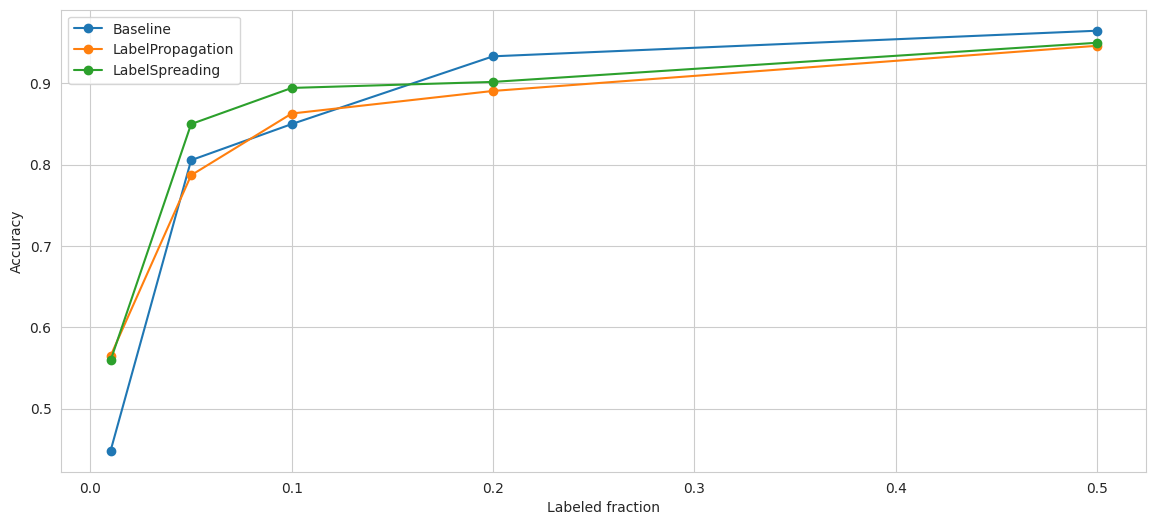

In [4]:
# Задача 3. Эксперименты с LabelPropagation и LabelSpreading

# TODO: задайте список долей размеченных данных
labeled_fractions = [0.01, 0.05, 0.10, 0.20, 0.50]

# TODO: подготовьте структуру для сохранения результатов (например, словарь или DataFrame)
results = []

# TODO: цикл по значениям labeled_fraction
# для каждого значения: создайте полу-контролируемую выборку, обучите baseline, LabelPropagation, LabelSpreading
# оцените accuracy (и при желании другие метрики) на тестовой выборке
for frac in labeled_fractions:
    (
        X_labeled,
        y_labeled,
        X_unlabeled,
        y_unlabeled_true,
        y_train_partial,
        labeled_idx,
        unlabeled_idx,
    ) = create_semi_supervised_split(
        X_train, y_train, labeled_fraction=frac, random_state=42
    )

    scaler = StandardScaler()
    scaler.fit(X_labeled)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    baseline = LogisticRegression(max_iter=1000)
    baseline.fit(scaler.transform(X_labeled), y_labeled)
    y_pred_base = baseline.predict(X_test_scaled)
    acc_base = accuracy_score(y_test, y_pred_base)

    lp = LabelPropagation()
    lp.fit(X_train_scaled, y_train_partial)
    y_pred_lp = lp.predict(X_test_scaled)
    acc_lp = accuracy_score(y_test, y_pred_lp)

    ls = LabelSpreading()
    ls.fit(X_train_scaled, y_train_partial)
    y_pred_ls = ls.predict(X_test_scaled)
    acc_ls = accuracy_score(y_test, y_pred_ls)

    results.append(
        {
            "labeled_fraction": frac,
            "Baseline": acc_base,
            "LabelPropagation": acc_lp,
            "LabelSpreading": acc_ls,
        }
    )

# TODO: преобразуйте результаты в DataFrame и выведите его
df_results = pd.DataFrame(results)
df_results

# TODO: постройте графики зависимости accuracy от доли размеченных данных для всех рассматриваемых методов
plt.figure()
plt.plot(df_results["labeled_fraction"], df_results["Baseline"], marker="o", label="Baseline")
plt.plot(df_results["labeled_fraction"], df_results["LabelPropagation"], marker="o", label="LabelPropagation")
plt.plot(df_results["labeled_fraction"], df_results["LabelSpreading"], marker="o", label="LabelSpreading")
plt.xlabel("Labeled fraction")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

При каких долях разметки SSL-методы дают наибольший выигрыш, в каких случаях преимущество уменьшается или исчезает?
Наибольший выигрыш получается при малых долях разметки 1–10%, на которых baseline-модель заметно проигрывает. При увеличении доли размеченных данных 20–50% преимущество SSL-методов уменьшается, а при высокой разметке практически исчезает

## Задача 4. Анализ и интерпретация результатов

На основе проделанных экспериментов ответьте на следующие вопросы (в текстовой ячейке ниже):

1. В каких условиях полу-контролируемое обучение дает наибольший выигрыш по сравнению с обучением только на размеченных данных.
2. Как меняется поведение Self-Training по сравнению с графовыми методами (LabelPropagation, LabelSpreading).
3. Какие гиперпараметры (например, `confidence_threshold`, `gamma`, `n_neighbors`, `alpha`) показались наиболее чувствительными к изменению и почему.
4. Какие потенциальные риски и ограничения SSL вы обнаружили на практике.

Сформулируйте выводы с отсылкой к полученным числовым результатам и графикам, а не только на уровне интуиции.

1. Полу-контролируемое обучение наиболее эффективно при малой доле размеченных данных и наличии хорошо выраженной структуры в данных

2. Self-Training дает более нестабильный прирост качества. Графовые методы работают стабильнее и показывают лучший результат при малом количестве разметки

3. Наиболее чувствительными оказались confidence_threshold у Self-Training и параметры ядра (gamma, n_neighbors, alpha) у графовых методов. Изменения этих параметров заметно влияют на качество из-за риска распространения ошибочных меток

4. Потенциальные риски из-за высокой чувствительности к гиперпараметрам и ухудшение качества при плохой структуре данных. SSL не гарантирует улучшения и при высокой доле разметки часто не дает выигрыша в отличии от supervised-подхода